# FuseMap Tutorial IV: Mapping to new datasets

In this tutorial, we will demonstrate how to map new spatial transcriptomics data to an existing FuseMap integration. This is useful when you want to analyze new samples in the context of previously integrated datasets.

FuseMap provides functionality to project new data points into the same latent space as the reference integration, allowing you to:

1. Compare new samples to existing integrated data
2. Transfer annotations and insights from the reference to new data
3. Analyze spatial patterns across old and new datasets together

We use the integrated model trained on merfish and starmap, and then transfer the model to slideseq.

- MERFISH data: Zhang et al. [Nature paper](https://www.nature.com/articles/s41586-023-06808-9#data-availability)
- STARmap data: Shi et al., [Nature paper](https://www.nature.com/articles/s41586-023-06569-5#data-availability)
- Slide-seq data: Langlieb et al., [Nature paper](https://www.nature.com/articles/s41586-023-06818-7#data-availability)

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

## 1. Get the reference model and the new dataset

The reference is the model you trained in **Tutorial 1** (MERFISH + STARmap integration,
`./output_tutorial1`). The new dataset to map is a Slide-seq puck the model has never seen.

In [2]:
import gdown

if not os.path.exists("./output_tutorial1/trained_model"):
    raise FileNotFoundError("Run Tutorial 1 first - its ./output_tutorial1 is the reference model here.")
os.makedirs("./tutorial4_data", exist_ok=True)
if not os.path.exists("./tutorial4_data/slideseq_Puck60.h5ad"):
    gdown.download(id="1wCjQSjRYxqf3gHZjtkYA2Xg9-QSoOwtq", output="./tutorial4_data/slideseq_Puck60.h5ad", quiet=False)

## 2. Map to the reference - one call

`fusemap.map_to_reference` projects the new data into the reference latent space
(the reference model is not retrained). One output subdirectory per input file.

In [3]:
import fusemap

pretrain_model_path = "./output_tutorial1"
fusemap.map_to_reference("./tutorial4_data", "./output_tutorial4", pretrain_model_path)

output_dir = "./output_tutorial4/slideseq_Puck60.h5ad"


2026-09-05 23:27:29,777 - INFO - 

---------------------------------- Preprocess adata ----------------------------------



2026-09-05 23:27:48,139 - INFO - 

---------------------------------- Construct graph adata ----------------------------------



2026-09-05 23:27:48,142 - INFO - 

---------------------------------- Process graph adata ----------------------------------



2026-09-05 23:27:48,191 - INFO - 

number of genes in each section:[19093], Number of all genes: 19093



2026-09-05 23:27:49,118 - INFO - 

pretrain gene number:1471, new gene number:17622



...

2026-09-05 23:27:52,322 - INFO - [FuseMap loader] atlas 0: dense CPU feature cache DISABLED (54787 x 19093 = 3.897 GB >= 2.0 GB limit); keeping scalable scipy CSR slicing.


2026-09-05 23:27:52,324 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=8, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-05 23:27:52,325 - INFO - [FuseMap loader] atlas 0: dense CPU feature cache DISABLED (54787 x 19093 = 3.897 GB >= 2.0 GB limit); keeping scalable scipy CSR slicing.


2026-09-05 23:27:52,325 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=8, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-05 23:27:52,347 - INFO - 

---------------------------------- Finish ----------------------------------



## 3. Transfer annotations to the mapped data — one call

The reference embedding (Tutorial 1's output) carries STARmap labels; the mapped Slide-seq
puck does not. We concatenate reference + query in the shared latent space and let
`fusemap.transfer_labels` do the rest — for cell types and tissue regions alike.

In [4]:
import anndata
import numpy as np
import pandas as pd

ref = sc.read_h5ad(os.path.join(pretrain_model_path, "ad_celltype_embedding.h5ad"))
qry = sc.read_h5ad(os.path.join(output_dir, "ad_celltype_embedding.h5ad"))

combo = anndata.AnnData(
    X=np.vstack([np.asarray(ref.X), np.asarray(qry.X)]),
    obs=pd.concat([ref.obs.assign(role="reference"), qry.obs.assign(role="query")]),
)
result = fusemap.transfer_labels(combo, label_key="gt_cell_type_main")
print(f"balanced held-out accuracy (reference): {result['test_accuracy']:.3f}")

qry.obs["cell_type"] = combo.obs["transfer_gt_cell_type_main"].values[ref.n_obs:]
qry.obs["cell_type_uncertainty"] = combo.obs["transfer_gt_cell_type_main_uncertainty"].values[ref.n_obs:]

balanced held-out accuracy (reference): 0.680


### Transferred cell types in space

Each panel shows one transferred cell type on the Slide-seq puck — spatially coherent
patterns (cortical layers, hippocampal bands) indicate a successful transfer.

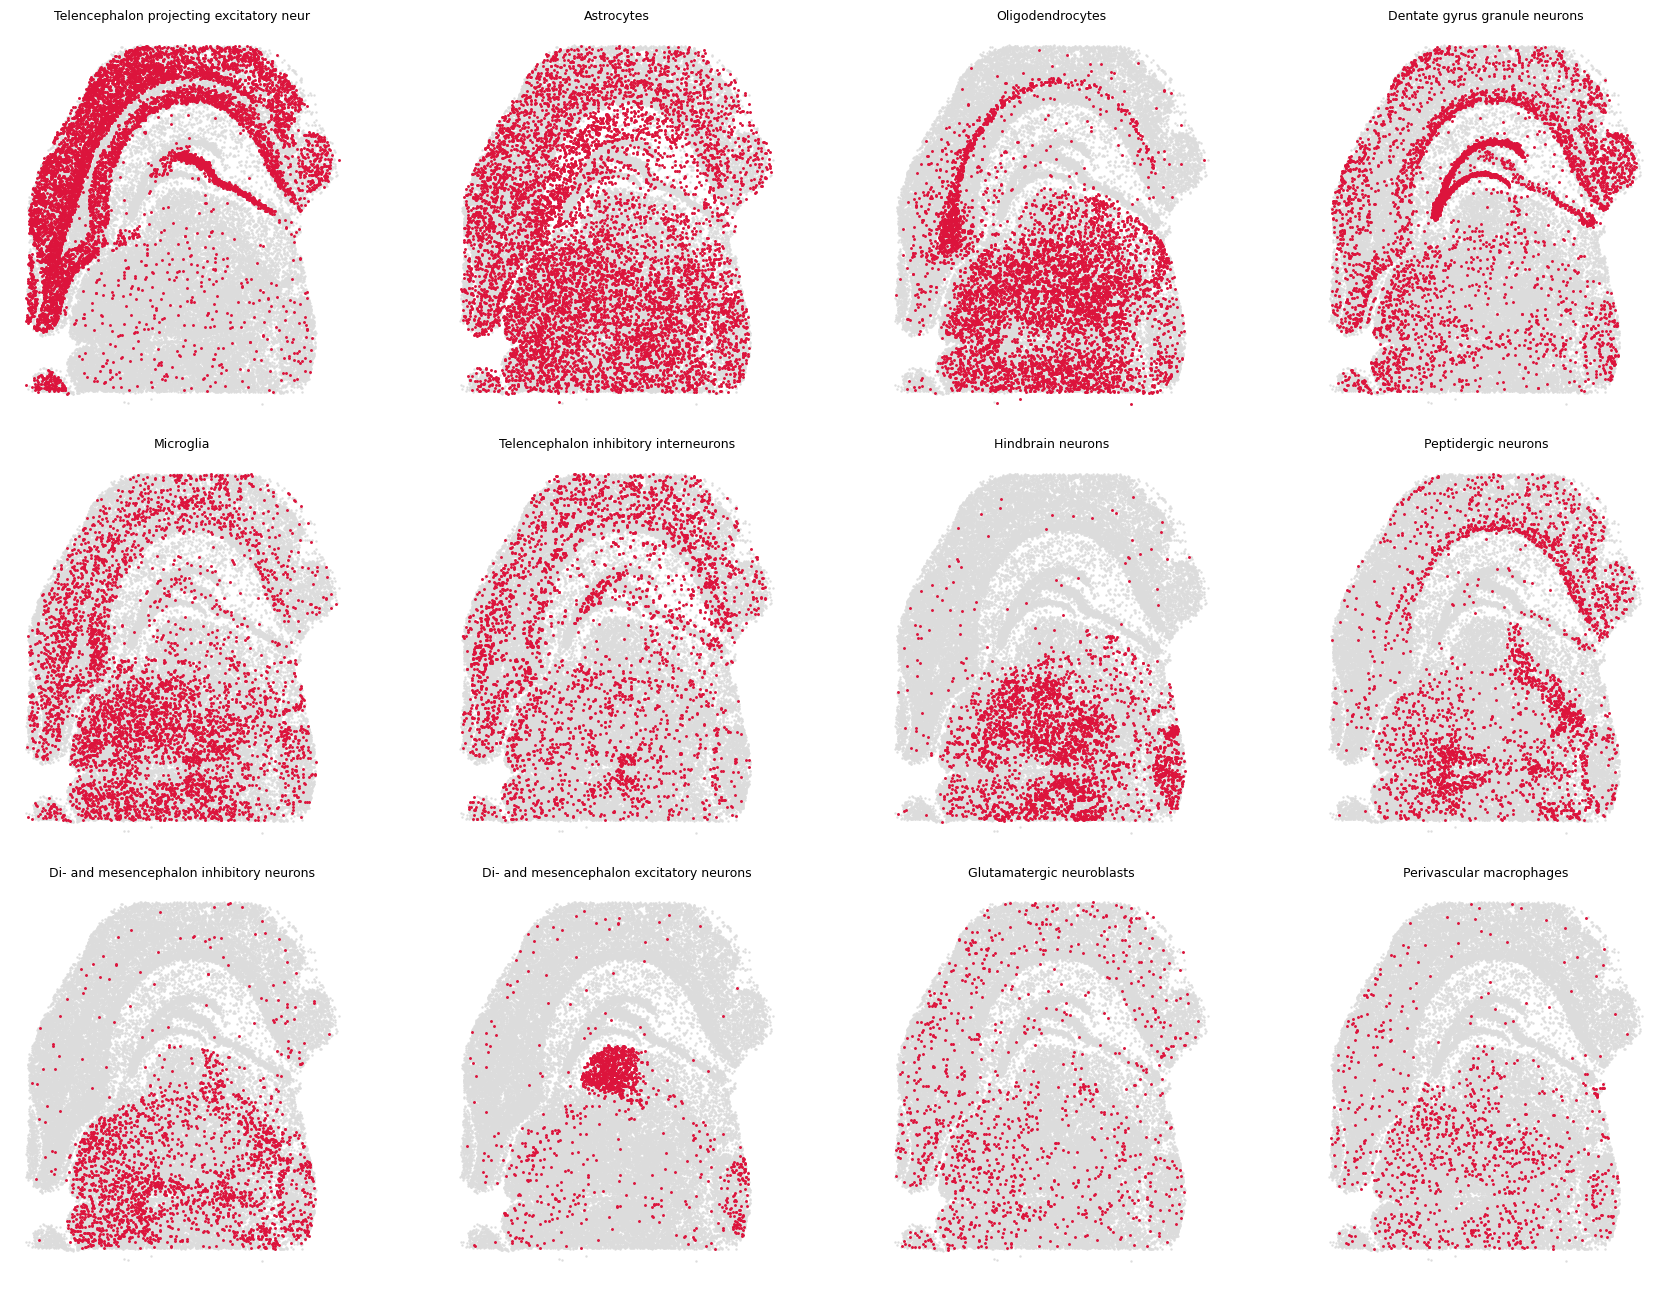

In [5]:
import matplotlib.pyplot as plt

top_types = qry.obs["cell_type"].value_counts().index[:12]
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
x, y = pd.to_numeric(qry.obs["x"]), pd.to_numeric(qry.obs["y"])
for ax, ct in zip(axes.flat, top_types):
    m = (qry.obs["cell_type"] == ct).values
    ax.scatter(x, y, s=0.5, color="gainsboro")
    ax.scatter(x[m], y[m], s=1.2, color="crimson")
    ax.set_title(str(ct)[:40], fontsize=9); ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
plt.tight_layout(); plt.show()

### Tissue regions, same recipe

balanced held-out accuracy (regions): 0.842


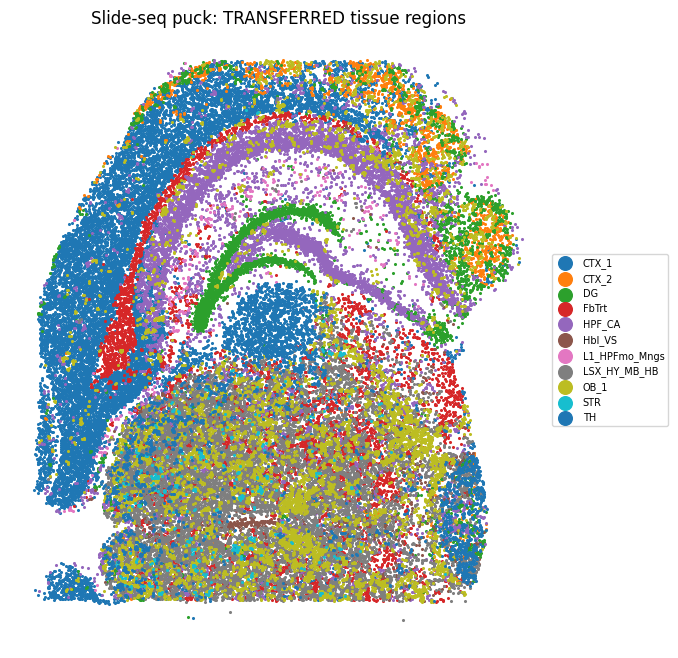

In [6]:
ref_t = sc.read_h5ad(os.path.join(pretrain_model_path, "ad_tissueregion_embedding.h5ad"))
qry_t = sc.read_h5ad(os.path.join(output_dir, "ad_tissueregion_embedding.h5ad"))
combo_t = anndata.AnnData(
    X=np.vstack([np.asarray(ref_t.X), np.asarray(qry_t.X)]),
    obs=pd.concat([ref_t.obs.assign(role="reference"), qry_t.obs.assign(role="query")]),
)
res_t = fusemap.transfer_labels(combo_t, label_key="gt_tissue_region_main")
qry_t.obs["tissue_region"] = combo_t.obs["transfer_gt_tissue_region_main"].values[ref_t.n_obs:]
print(f"balanced held-out accuracy (regions): {res_t['test_accuracy']:.3f}")

fig, ax = plt.subplots(figsize=(8, 8))
xt, yt = pd.to_numeric(qry_t.obs["x"]), pd.to_numeric(qry_t.obs["y"])
for reg in sorted(qry_t.obs["tissue_region"].astype(str).unique()):
    m = (qry_t.obs["tissue_region"].astype(str) == reg).values
    if m.sum() > 50:
        ax.scatter(xt[m], yt[m], s=1.5, label=reg)
ax.set_title("Slide-seq puck: TRANSFERRED tissue regions")
ax.legend(markerscale=8, fontsize=7, loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
plt.show()

## When to map vs when to integrate

Mapping projects new data into a **frozen** reference space — quality depends on the reference's
scale and diversity. Rules of thumb:

- **molCCF** (13.8M cells, many technologies): mapping works well — see Tutorial 5.
- **Small custom references** (a few sections): results vary with how well the reference covers
  the query's platform and regions. If the mapped sample does not mix with the reference in UMAP,
  **integrate the new sample together with the reference sections instead**
  (`fusemap.integrate` on all files jointly) — slower, but always the more accurate option.